First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant 

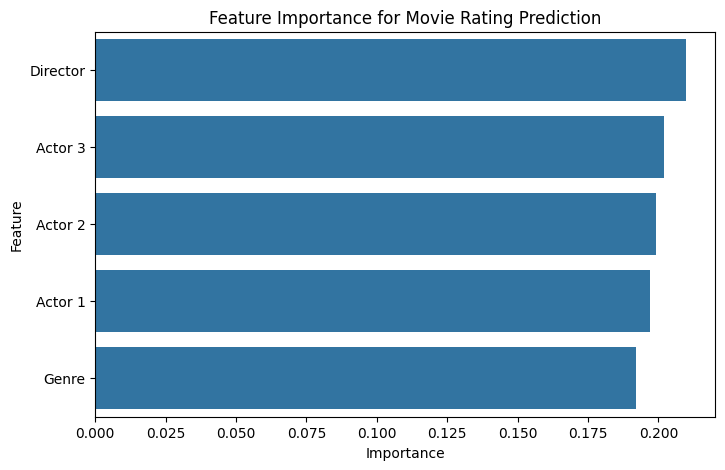

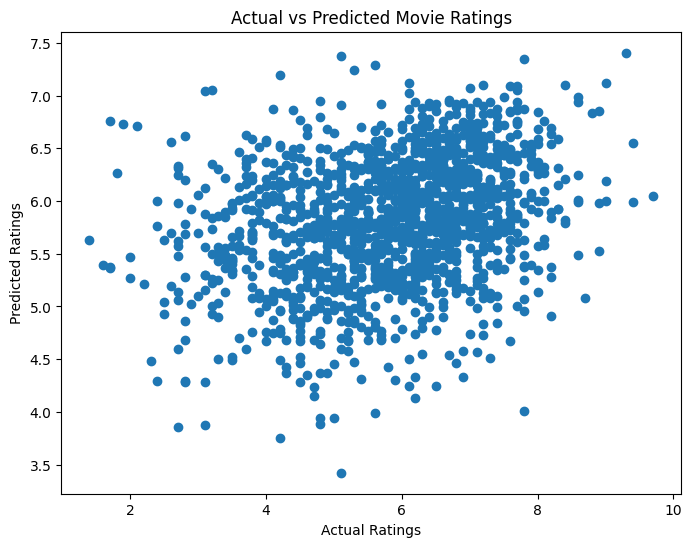


Predicted Movie Rating: 6.377000000000004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [1]:
# MOVIE RATING PREDICTION WITH PYTHON

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
# Replace filename with your dataset file name
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

# Display First Rows
print("First 5 Rows:")
print(df.head())

# Dataset Information
print("\nDataset Information:")
print(df.info())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Select Required Columns
df = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']]

# Remove Missing Values
df.dropna(inplace=True)

# Convert Rating to Numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Remove Remaining Null Values
df.dropna(inplace=True)

# Label Encoding
le_genre = LabelEncoder()
le_director = LabelEncoder()
le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_actor3 = LabelEncoder()

df['Genre'] = le_genre.fit_transform(df['Genre'])
df['Director'] = le_director.fit_transform(df['Director'])
df['Actor 1'] = le_actor1.fit_transform(df['Actor 1'])
df['Actor 2'] = le_actor2.fit_transform(df['Actor 2'])
df['Actor 3'] = le_actor3.fit_transform(df['Actor 3'])

# Features and Target
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]
y = df['Rating']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-" * 30)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

# Actual vs Predicted Comparison
results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print("\nSample Predictions:")
print(results.head(10))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance for Movie Rating Prediction')
plt.show()

# Scatter Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

# Example Prediction
# Use values from your dataset after encoding
sample_movie = [[0, 0, 0, 0, 0]]

predicted_rating = model.predict(sample_movie)

print("\nPredicted Movie Rating:", predicted_rating[0])